# Optimization with Simulated Annealing

## Introduction

This notebook documents an optimization module that can be used to optimize player locations in a single tracking frame. The optimization currently only supports the **Simulated Annealing** algorithm, and allows creation of any arbitrary objective or constraint.

The approach is useful for use cases such as:

- Finding defensive repositioning that maximizes xT-weighted pitch control.
- Evaluating trade-offs between pitch control and pressure.
- Measuring how far a team's position is from some theoretical optimal.


```{warning}
Although we try to keep everything up to date, notebook examples can evolve slightly differently from the package internals. If you spot inconsistencies, please open an issue.
```

## Optimization setup

The high-level API is `optimize_tracking_frame()`. You provide:

1. a game and selected frame,
2. objective terms,
3. optional constraints,
4. an optimization algorithm (`SimulatedAnnealing` in this example),
5. algorithm specific hyperparameters like `num_iterations`.

In [1]:
from copy import deepcopy

import numpy as np
import pandas as pd
from kloppy import skillcorner
from matplotlib.colors import LinearSegmentedColormap

from databallpy import get_game_from_kloppy
from databallpy.features.pitch_control import (
    get_pitch_control_single_frame,
    get_team_influence,
)
from databallpy.optimization.constraints import TTIConstraint
from databallpy.optimization.objectives import (
    PressureObjective,
    WeightedPitchControlObjective,
)
from databallpy.optimization.optimization import optimize_tracking_frame
from databallpy.optimization.simulated_annealing import SimulatedAnnealing
from databallpy.visualize import plot_soccer_pitch, plot_tracking_data

## Load tracking frame

We'll start by picking one frame from this match, where the Green team LCB is making a pass to the LB.

/Users/amar/Documents/databallpy/databallpy/utils/get_game.py:921: UserWarning: All frames in 'tracking_dataset' are 'ALIVE', databallpy expects 'DEAD' frames as well (e.g. for more accurate event synchronization). Set `only_alive=False` in your kloppy `.load_tracking()` call to include 'DEAD' frames.
  warnings.warn(


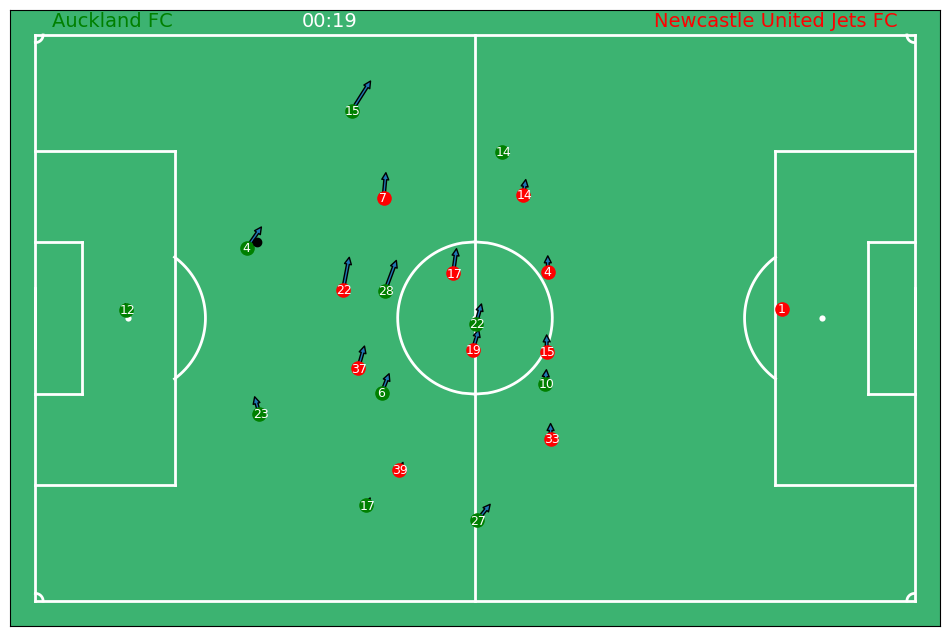

In [2]:
match_id = 1886347
tracking_data_github_url = (
    "https://media.githubusercontent.com/media/SkillCorner/opendata/master/data/"
    f"matches/{match_id}/{match_id}_tracking_extrapolated.jsonl"
)
meta_data_github_url = (
    "https://raw.githubusercontent.com/SkillCorner/opendata/master/data/"
    f"matches/{match_id}/{match_id}_match.json"
)

dataset = skillcorner.load(
    meta_data=meta_data_github_url,
    raw_data=tracking_data_github_url,
    coordinates="skillcorner",
    limit=500,
)

game = get_game_from_kloppy(dataset)
game.tracking_data.add_velocity(game.get_column_ids() + ["ball"], allow_overwrite=True)
game.tracking_data.add_individual_player_possession()

selected_frame_idx = 210
frame = game.tracking_data[game.tracking_data["frame"] == selected_frame_idx].iloc[0]
#frame id is not the same as index
idx_relative_to_game = game.tracking_data[game.tracking_data["frame"] == selected_frame_idx].index[0]

fig, ax = plot_tracking_data(
        game,
        idx_relative_to_game,
        team_colors=["green", "red"],
        add_velocities=True,
    )

## Build objective terms and constraints

For this example, we will define an objective function containing two objective terms:

- `WeightedPitchControlObjective`: rewards pitch-control effects from defensive movement (weight = 1)
- `PressureObjective`: rewards pressure on the attacking side (weight = 1)

We constrain the algorithm with `TTIConstraint`, so players are only moved to physically reachable locations within a given time-to-intercept window, in this case 2 seconds)

In [ ]:

attacking_team = frame["team_possession"]
defending_team = "home" if attacking_team == "away" else "away"

objective_terms = [
    WeightedPitchControlObjective(
        game=game,
        frame=frame,
    ),
    PressureObjective(
        game=game,
        frame=frame,
    ),
]
weights = [1, 1]
constraints = [TTIConstraint(game, frame,max_time_to_intercept_seconds=2)]


## Run simulated annealing

Now we call the optimization API with `SimulatedAnnealing` as the algorithm backend. Internally this performs repeated perturbations and probabilistic acceptance steps to search for a strong tactical configuration.

In [10]:
result = optimize_tracking_frame(
    game=game,
    selected_frame_idx=selected_frame_idx,
    objective_terms=objective_terms,
    weights=weights,
    constraints=constraints,
    algorithm=SimulatedAnnealing,
    num_iterations=1000,
)

print("Best objective value:", result.best_result)

Best objective value: 23847.34865429709


## Visualize original vs optimized frame

The helper functions below are copied from the prototype script and allow plotting a single frame and a transparent overlay difference between the original and optimized positions.

In [11]:
def diff_frames(game_1, frame_idx_1, game_2, frame_idx_2):
    frame_1 = game_1.tracking_data[game_1.tracking_data["frame"] == frame_idx_1].iloc[0]
    frame_2 = game_2.tracking_data[game_2.tracking_data["frame"] == frame_idx_2].iloc[0]

    pitch_control_2 = get_pitch_control_single_frame(
        frame_2,
        game_2.pitch_dimensions,
        n_x_bins=106,
        n_y_bins=68,
    )
    cmap_red_green = LinearSegmentedColormap.from_list(
        "reds", [(0, 1, 0, 1), (0.5, 0.5, 0, 0), (1, 0, 0, 1)]
    )

    fig, ax = plot_soccer_pitch(field_dimen=game.pitch_dimensions, pitch_color="white")
    idx_relative_to_game_1 = game_1.tracking_data[
        game_1.tracking_data["frame"] == frame_idx_1
    ].index[0]
    idx_relative_to_game_2 = game_2.tracking_data[
        game_2.tracking_data["frame"] == frame_idx_2
    ].index[0]

    fig, ax = plot_tracking_data(
        game_1,
        idx_relative_to_game_1,
        team_colors=["green", "red"],
        ax=ax,
        fig=fig,
        add_velocities=True,
        alpha=0.4
    )
    fig, ax = plot_tracking_data(
        game_2,
        idx_relative_to_game_2,
        team_colors=[(0.0, 1.0, 0.0, 0.5), (1.0, 0.0, 0.0, 0.5)],
        ax=ax,
        fig=fig,
        heatmap_overlay=pitch_control_2,
        overlay_cmap=cmap_red_green,
        add_velocities=True,
    )
    return fig, ax

/Users/amar/Documents/databallpy/databallpy/visualize.py:874: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  fig_obj = ax.scatter(
/Users/amar/Documents/databallpy/databallpy/visualize.py:874: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  fig_obj = ax.scatter(


(<Figure size 1200x800 with 1 Axes>, <Axes: >)

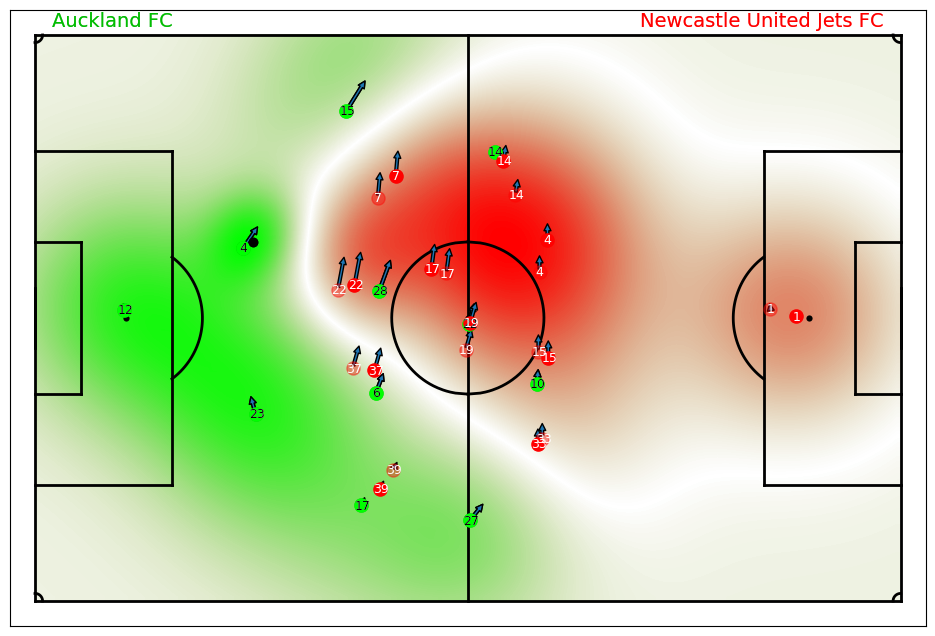

In [13]:
new_game = deepcopy(game)
new_game.tracking_data = pd.DataFrame(result.best_frame).transpose().reset_index()

fig, ax = diff_frames(
    game,
    selected_frame_idx,
    new_game,
    selected_frame_idx,
)
fig, ax

## Conclusion

You now have a complete end-to-end example for frame-level tactical optimization with simulated annealing:

- loading and preparing tracking data,
- defining objective terms and constraints,
- running the optimizer,
- and comparing baseline vs optimized outcomes visually.

You can extend this setup by tuning objective weights, changing constraints, or plugging in additional optimization algorithms exposed by the optimization module.